# 7C. Fusión y comparación audio ↔ texto (corpus completo)

Este notebook cruza, a nivel de **todo el corpus**, las dos modalidades de análisis afectivo generadas antes:

- **Notebook 07A** — sentimiento **textual**: qué se dice.
- **Notebook 07B** — afecto de **audio**: cómo suena (prosodia + modelo SER).

El 10 (demo end-to-end) ya mostraba este cruce para *un* audio a la vez, a modo ilustrativo. Aquí se cuantifica sobre el conjunto de segmentos disponible, para obtener conclusiones estadísticamente más robustas que un solo ejemplo.

**Preguntas que responde:**
1. ¿Cuántos segmentos tienen ambas modalidades disponibles?
2. ¿Cuánto se parecen el sentimiento textual y los scores de audio? (concordancia)
3. ¿Dónde discrepan, y qué significa esa discrepancia? (frustración enmascarada: texto neutro/positivo con voz tensa)
4. ¿Cómo difiere el perfil afectivo entre agente y cliente, combinando ambas fuentes?

**Entradas:** el CSV de comparación que ya genera el Notebook 07B (`audio_vs_textual_sentiment_comparison.csv`); si no existe, este notebook lo reconstruye a partir de los outputs de 07A y 07B por separado.

**Salidas:** CSVs con el detalle segmento a segmento, correlaciones, matriz de confusión, ejemplos de discordancia y agregados por rol/llamada — pensados para citarse directamente en la memoria.

**Nota de alcance:** este notebook depende de que 07A y 07B ya se hayan ejecutado. Si algún output todavía no existe, cada fase lo indica y se salta con elegancia en vez de fallar.

In [1]:
# ============================================================
# CELDA 1 - IMPORTS
# ============================================================

from pathlib import Path
import os
import re
import json
import warnings
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

try:
    from scipy.stats import pearsonr, spearmanr
    HAS_SCIPY = True
except Exception:
    HAS_SCIPY = False

try:
    from google.cloud import storage
    GCS_AVAILABLE = True
except Exception:
    GCS_AVAILABLE = False

from IPython.display import display, HTML, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)

print("Imports cargados.")
print("scipy disponible:", HAS_SCIPY, "| GCS disponible:", GCS_AVAILABLE)


Imports cargados.
scipy disponible: True | GCS disponible: True


In [2]:
# ============================================================
# CELDA 2 - CONFIGURACIÓN DE RUTAS, PARÁMETROS Y ESTILO
# ============================================================

PROJECT_DIR = Path("/home/jupyter/TFM_ProcesadoDeAudios")
DATA_DIR = PROJECT_DIR / "data"

# --- Entradas ---
# Comparación segmento a segmento que ya genera el Notebook 07B (preferente)
PROSODY_DIR = DATA_DIR / "prosody_outputs"
AUDIO_TEXT_COMPARISON_CSV = PROSODY_DIR / "audio_vs_textual_sentiment_comparison.csv"

# Fuentes originales, por si hay que reconstruir la fusión
SEGMENTS_PROSODY_CSV = PROSODY_DIR / "segments_with_audio_affect_prosody.csv"          # 07B
SENTIMENT_DIR = DATA_DIR / "sentiment_outputs"
TEXTUAL_SENTIMENT_CANDIDATES = [                                                        # 07A
    SENTIMENT_DIR / "all_segments_sentiment_textual_enriched.csv",
    SENTIMENT_DIR / "segments_with_sentiment_textual.csv",
]

# --- Salidas del 7C ---
FUSION_DIR = DATA_DIR / "sentiment_fusion_outputs"
FIGURES_DIR = FUSION_DIR / "figures"
FUSION_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

FUSION_SEGMENTS_CSV = FUSION_DIR / "segments_audio_text_fusion.csv"
CORRELATIONS_CSV = FUSION_DIR / "correlations_audio_text.csv"
CONFUSION_CSV = FUSION_DIR / "confusion_prosodic_state_vs_sentiment.csv"
DISAGREEMENT_SEGMENTS_CSV = FUSION_DIR / "disagreement_masked_frustration_segments.csv"
ROLE_LEVEL_CSV = FUSION_DIR / "role_level_audio_text_fusion.csv"
CALL_LEVEL_CSV = FUSION_DIR / "call_level_audio_text_fusion.csv"
SUMMARY_MEMORY_CSV = FUSION_DIR / "fusion_summary_for_memory.csv"

# --- Parámetros de análisis ---
# Percentil que define "audio activado/tenso" para el análisis de discordancia
AUDIO_HIGH_PERCENTILE = 75
# Sentimiento textual: umbral para considerar el texto "no negativo"
TEXT_NONNEG_THRESHOLD = 0.0   # sentiment_numeric >= 0 => neutral/positivo

# --- Subida opcional a GCS ---
UPLOAD_TO_GCS = False
GCS_BUCKET_NAME = ""
GCS_PREFIX = "TFM_ProcesadoDeAudios/data/sentiment_fusion_outputs"

# --- Estilo visual (coherente con Notebook 10) ---
TFM_CYCLE = ["#2563EB", "#F97316", "#059669", "#C1272D", "#7C3AED", "#0891B2", "#E8A33D", "#6B7280"]
TINTA, AZUL, NARANJA, VERDE, GRIS = "#0F3D5C", "#2563EB", "#F97316", "#059669", "#6B7280"
plt.rcParams.update({
    "figure.figsize": (11, 4.2), "axes.grid": True, "grid.alpha": 0.2,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.titlesize": 13,
    "axes.prop_cycle": plt.cycler(color=TFM_CYCLE),
})

display(HTML("""
<style>
.f7c-hero{border-radius:14px;padding:16px 20px;margin:4px 0 14px 0;
 background:linear-gradient(135deg,#0F3D5C 0%,#2563EB 100%);color:white;}
.f7c-sec{border-left:4px solid #2563EB;padding:4px 0 4px 12px;margin:18px 0 8px 0;}
.f7c-sec .t{font-size:16px;font-weight:700;color:#111827;}
.f7c-sec .s{font-size:12px;color:#6B7280;}
.f7c-card{display:flex;flex-wrap:wrap;gap:8px;margin:8px 0 14px 0;}
.f7c-kpi{border:1px solid #E5E7EB;border-radius:10px;padding:10px 14px;background:white;min-width:140px;}
.f7c-kpi .v{font-size:22px;font-weight:700;color:#0F3D5C;}
.f7c-kpi .l{color:#6B7280;font-size:12px;}
.f7c-note{background:#F8FAFC;border:1px solid #E5E7EB;border-radius:10px;padding:10px 14px;margin:8px 0;font-size:13px;color:#374151;}
</style>
"""))

def sec(title, subtitle=None):
    s = f"<div class='s'>{subtitle}</div>" if subtitle else ""
    display(HTML(f"<div class='f7c-sec'><div class='t'>{title}</div>{s}</div>"))

def kpis(metrics):
    html = "<div class='f7c-card'>"
    for l, v in metrics.items():
        vv = f"{v:,.2f}" if isinstance(v, float) else (f"{v:,}".replace(",", ".") if isinstance(v, int) else str(v))
        html += f"<div class='f7c-kpi'><div class='v'>{vv}</div><div class='l'>{l}</div></div>"
    display(HTML(html + "</div>"))

def note(text):
    display(HTML(f"<div class='f7c-note'>{text}</div>"))

print("Config lista. FUSION_DIR:", FUSION_DIR)
print("Entrada preferente (07B comparison):", AUDIO_TEXT_COMPARISON_CSV.exists())


Config lista. FUSION_DIR: /home/jupyter/TFM_ProcesadoDeAudios/data/sentiment_fusion_outputs
Entrada preferente (07B comparison): True


## Carga y fusión de datos

Se usa preferentemente el CSV de comparación que ya arma el Notebook 07B. Si no existe (por ejemplo, si 07B se ejecutó antes de tener 07A disponible), se reconstruye la fusión uniendo ambos outputs por audio + timestamp.

In [3]:
# ============================================================
# CELDA 3 - FUNCIONES AUXILIARES Y CARGA/RECONSTRUCCIÓN DE LA FUSIÓN
# ============================================================

def read_csv_safe(path):
    path = Path(path)
    if not path.exists() or path.stat().st_size == 0:
        return pd.DataFrame()
    try:
        return pd.read_csv(path)
    except Exception as e:
        print(f"No se pudo leer {path.name}: {e}")
        return pd.DataFrame()

def first_existing(paths):
    for p in paths:
        if Path(p).exists() and Path(p).stat().st_size > 0:
            return Path(p)
    return None

def detect_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def normalize_audio_stem(v):
    if pd.isna(v):
        return ""
    v = Path(str(v)).name
    v = re.sub(r"\.(wav|mp3|m4a|flac|ogg)$", "", v, flags=re.IGNORECASE)
    for suf in ["_final_segments", "_final_merged", "_transcribed_segments", "_raw"]:
        if v.endswith(suf):
            v = v[: -len(suf)]
    return v

def normalize_sentiment_label(v):
    # Alineado con el Notebook 07: las etiquetas se normalizan a
    # negative / neutral / positive (en inglés), que es lo que produce
    # pysentimiento/robertuito y lo que espera sentiment_label_to_numeric.
    if pd.isna(v):
        return np.nan
    s = str(v).strip().lower()
    if s in {"pos", "positive", "positivo", "label_2", "5 stars", "4 stars"}:
        return "positive"
    if s in {"neg", "negative", "negativo", "label_0", "1 star", "2 stars"}:
        return "negative"
    if s in {"neu", "neutral", "label_1", "3 stars"}:
        return "neutral"
    return s


def sentiment_label_to_numeric(label):
    # Mismo mapeo que el Notebook 07 (sentiment_to_numeric):
    # negative = -1, neutral = 0, positive = +1.
    mapping = {"negative": -1, "neutral": 0, "positive": 1}
    return mapping.get(label, np.nan)

def find_ser_negative_prob_col(df):
    neg = ["enfado", "enojo", "ira", "anger", "angry", "rabia", "tristeza", "sad",
           "disgust", "asco", "miedo", "fear", "frustrac", "negative", "negativo"]
    probs = [c for c in df.columns if str(c).startswith("ser_prob_")]
    for c in probs:
        if any(t in c.lower() for t in ["enfado", "anger", "angry", "ira", "rabia"]):
            return c
    for c in probs:
        if any(t in c.lower() for t in neg):
            return c
    return None


def build_fusion():
    """Devuelve el dataframe fusionado segmento a segmento (audio 07B + texto 07A).

    Estrategia:
      1) Si existe el CSV de comparación del 07B, se usa como base.
      2) Si no, se reconstruye uniendo 07B y 07A por (audio_stem_norm, start, end) redondeados.
    Normaliza nombres de columnas a un esquema común.
    """
    base = read_csv_safe(AUDIO_TEXT_COMPARISON_CSV)
    source = "comparison_07B"

    if base.empty:
        # Reconstrucción desde fuentes
        df_audio = read_csv_safe(SEGMENTS_PROSODY_CSV)
        text_path = first_existing(TEXTUAL_SENTIMENT_CANDIDATES)
        df_text = read_csv_safe(text_path) if text_path else pd.DataFrame()

        if df_audio.empty or df_text.empty:
            return pd.DataFrame(), "sin_datos"

        a_stem = detect_col(df_audio, ["audio_stem_norm", "audio_stem", "audio_file_norm", "audio_file"])
        a_s = detect_col(df_audio, ["start", "start_sec", "start_time"])
        a_e = detect_col(df_audio, ["end", "end_sec", "end_time"])
        df_audio["audio_stem_norm"] = df_audio[a_stem].apply(normalize_audio_stem)
        df_audio["start_round"] = pd.to_numeric(df_audio[a_s], errors="coerce").round(3)
        df_audio["end_round"] = pd.to_numeric(df_audio[a_e], errors="coerce").round(3)

        t_stem = detect_col(df_text, ["audio_stem_norm", "audio_stem", "audio_file", "filename"])
        t_s = detect_col(df_text, ["start", "start_sec", "start_time"])
        t_e = detect_col(df_text, ["end", "end_sec", "end_time"])
        df_text["audio_stem_norm"] = df_text[t_stem].apply(normalize_audio_stem)
        df_text["start_round"] = pd.to_numeric(df_text[t_s], errors="coerce").round(3)
        df_text["end_round"] = pd.to_numeric(df_text[t_e], errors="coerce").round(3)

        keep = ["audio_stem_norm", "start_round", "end_round"]
        for c in ["sentiment_label", "sentiment_numeric", "sentiment_score", "text_whisper", "role_proxy", "speaker_final"]:
            if c in df_text.columns:
                keep.append(c)

        base = df_audio.merge(
            df_text[keep].drop_duplicates(["audio_stem_norm", "start_round", "end_round"]),
            on=["audio_stem_norm", "start_round", "end_round"], how="left"
        )
        source = "reconstruido_07A+07B"

    # --- Normalización a esquema común ---
    df = base.copy()

    # audio / tiempo
    if "audio_stem_norm" not in df.columns:
        c = detect_col(df, ["audio_stem", "audio_file_norm", "audio_file"])
        df["audio_stem_norm"] = df[c].apply(normalize_audio_stem) if c else np.nan
    for tcol in ["start", "end"]:
        if tcol not in df.columns:
            alt = detect_col(df, [f"{tcol}_round", f"{tcol}_sec", f"{tcol}_time"])
            if alt:
                df[tcol] = pd.to_numeric(df[alt], errors="coerce")

    # rol y speaker unificados
    role_col = detect_col(df, ["role_proxy_for_prosody", "role_proxy", "official_role_proxy", "probable_role"])
    df["role"] = df[role_col].astype(str).str.lower() if role_col else "desconocido"
    spk_col = detect_col(df, ["speaker_for_prosody", "speaker_final", "speaker"])
    df["speaker"] = df[spk_col] if spk_col else np.nan

    # scores de audio (07B)
    for c in ["arousal_proxy_score", "tension_proxy_score", "intensity_proxy_score", "calm_proxy_score"]:
        if c not in df.columns:
            df[c] = np.nan
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # SER negativo
    ser_neg = find_ser_negative_prob_col(df)
    df["ser_neg_prob"] = pd.to_numeric(df[ser_neg], errors="coerce") if ser_neg else np.nan
    if "ser_pred_label" in df.columns:
        df["ser_pred_label_norm"] = df["ser_pred_label"].apply(normalize_sentiment_label)

    # sentimiento textual (07A)
    if "sentiment_label" in df.columns:
        df["sentiment_label_norm"] = df["sentiment_label"].apply(normalize_sentiment_label)
    else:
        df["sentiment_label_norm"] = np.nan
    if "sentiment_numeric" not in df.columns:
        df["sentiment_numeric"] = np.nan
    df["sentiment_numeric"] = pd.to_numeric(df["sentiment_numeric"], errors="coerce")

    # FIX: si sentiment_numeric no vino en el CSV base (o llegó vacío),
    # derivarlo desde la etiqueta textual ya normalizada. Sin esto, todo
    # el cruce audio<->texto quedaba en NaN (correlaciones, confusión y
    # perfiles por rol salían vacíos).
    needs_numeric = df["sentiment_numeric"].isna() & df["sentiment_label_norm"].notna()
    if needs_numeric.any():
        df.loc[needs_numeric, "sentiment_numeric"] = (
            df.loc[needs_numeric, "sentiment_label_norm"].apply(sentiment_label_to_numeric)
        )

    # flags de disponibilidad de cada modalidad
    df["has_audio"] = df["arousal_proxy_score"].notna() | df["tension_proxy_score"].notna()
    df["has_text"] = df["sentiment_numeric"].notna() | df["sentiment_label_norm"].notna()

    return df, source


df_fusion, FUSION_SOURCE = build_fusion()
print("Origen de la fusión:", FUSION_SOURCE)
print("Segmentos fusionados:", len(df_fusion))
if not df_fusion.empty:
    display(df_fusion[[c for c in ["audio_stem_norm", "role", "arousal_proxy_score",
        "tension_proxy_score", "ser_neg_prob", "sentiment_label_norm", "sentiment_numeric",
        "has_audio", "has_text"] if c in df_fusion.columns]].head(8))


Origen de la fusión: comparison_07B
Segmentos fusionados: 35910


,audio_stem_norm,role,arousal_proxy_score,tension_proxy_score,ser_neg_prob,sentiment_label_norm,sentiment_numeric,has_audio,has_text
0,raw_9154117451310006851_clean,agent,0.521993,0.610595,0.163730,neutral,0.0,True,True
1,raw_9154117451310006851_clean,client,0.441332,0.275878,0.192789,neutral,0.0,True,True
2,raw_9154117451310006851_clean,agent,0.455894,0.457755,0.163743,positive,1.0,True,True
3,raw_9154117451310006851_clean,client,0.549870,0.452922,0.159235,NaN,NaN,True,False
4,raw_9154117451310006851_clean,agent,0.617328,0.798132,0.163592,neutral,0.0,True,True
5,raw_9154117451310006851_clean,agent,0.994615,1.000000,0.133799,neutral,0.0,True,True
6,raw_9154117451310006851_clean,agent,0.406635,0.345311,0.155737,neutral,0.0,True,True
7,raw_9154117451310006851_clean,agent,0.152493,0.265761,0.182940,negative,-1.0,True,True


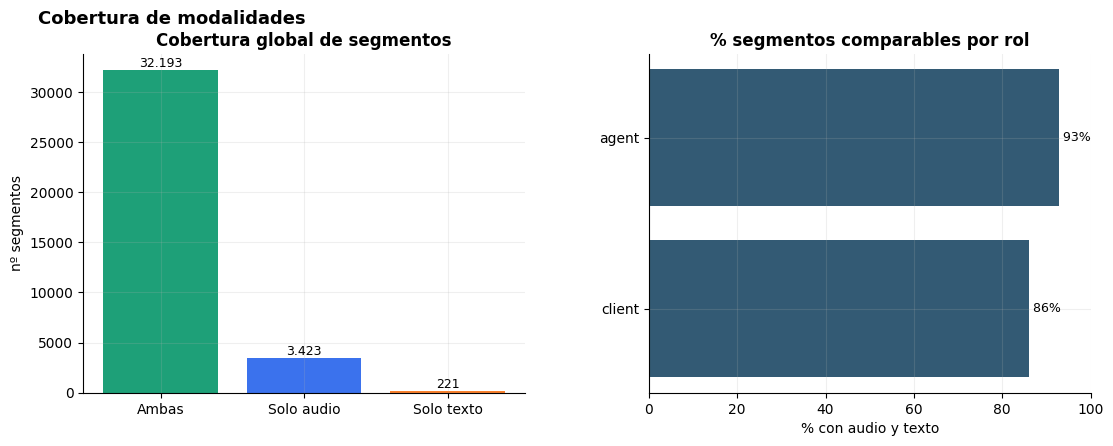

In [4]:
# ============================================================
# CELDA 4 - FASE 1 · COBERTURA DE MODALIDADES
# ============================================================
# ¿En cuántos segmentos tenemos audio, texto, o ambos? Sin esto,
# cualquier comparación posterior estaría sesgada.

sec("Fase 1 · Cobertura de modalidades",
    "Cuántos segmentos disponen de afecto de audio (07B), sentimiento textual (07A) o ambos.")

if df_fusion.empty:
    note("No hay datos de fusión. Ejecuta antes 07A y 07B para generar sus outputs.")
else:
    n = len(df_fusion)
    both = int((df_fusion["has_audio"] & df_fusion["has_text"]).sum())
    only_audio = int((df_fusion["has_audio"] & ~df_fusion["has_text"]).sum())
    only_text = int((~df_fusion["has_audio"] & df_fusion["has_text"]).sum())

    kpis({
        "segmentos totales": n,
        "con ambas modalidades": both,
        "solo audio": only_audio,
        "solo texto": only_text,
        "% comparables": round(100 * both / max(1, n), 1),
    })

    # Panel: cobertura global + cobertura por rol
    fig = plt.figure(figsize=(13, 4.4))
    gs = GridSpec(1, 2, wspace=0.28)

    ax0 = fig.add_subplot(gs[0])
    labels = ["Ambas", "Solo audio", "Solo texto"]
    vals = [both, only_audio, only_text]
    ax0.bar(labels, vals, color=[VERDE, AZUL, NARANJA], alpha=0.9)
    for i, v in enumerate(vals):
        ax0.text(i, v, f"{v:,}".replace(",", "."), ha="center", va="bottom", fontsize=9)
    ax0.set_title("Cobertura global de segmentos", fontsize=12)
    ax0.set_ylabel("nº segmentos")

    ax1 = fig.add_subplot(gs[1])
    if "role" in df_fusion.columns:
        cov = df_fusion.assign(comparable=df_fusion["has_audio"] & df_fusion["has_text"]) \
                       .groupby("role")["comparable"].mean().sort_values() * 100
        ax1.barh(cov.index.astype(str), cov.values, color=TINTA, alpha=0.85)
        for i, v in enumerate(cov.values):
            ax1.text(v, i, f" {v:.0f}%", va="center", fontsize=9)
        ax1.set_xlim(0, 100)
        ax1.set_title("% segmentos comparables por rol", fontsize=12)
        ax1.set_xlabel("% con audio y texto")
    fig.suptitle("Cobertura de modalidades", fontsize=13, fontweight="bold", x=0.09, ha="left")
    plt.savefig(FIGURES_DIR / "fase1_cobertura.png", dpi=120, bbox_inches="tight", facecolor="white")
    plt.show()

    note(f"Solo los <b>{both:,}</b> segmentos con ambas modalidades entran en el análisis de "
         f"concordancia/discordancia. El resto se reserva para lecturas de una sola modalidad."
         .replace(",", "."))


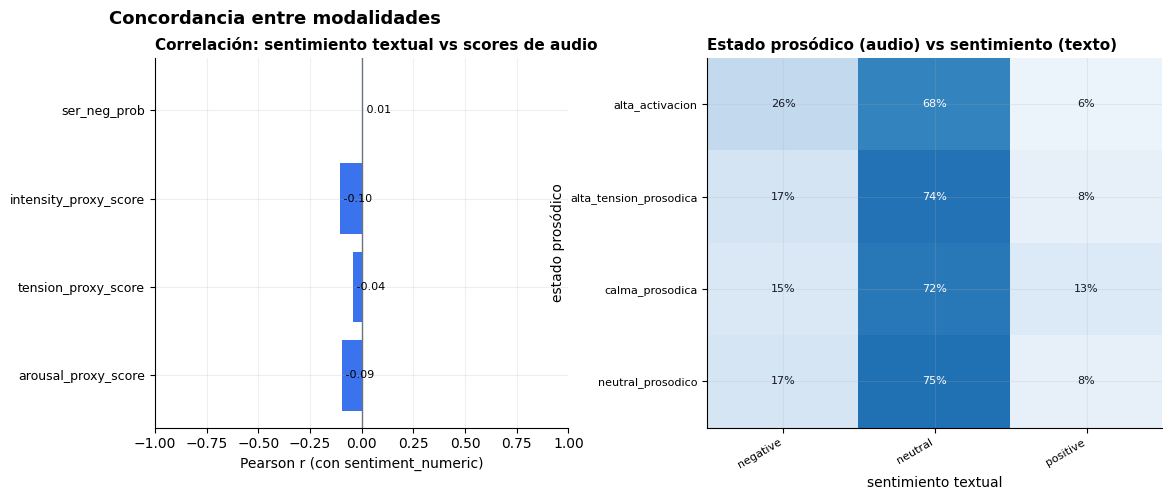

,score_audio,n,pearson_r,pearson_p,spearman_r,spearman_p
0,arousal_proxy_score,32193,-0.093,0.0000,-0.090,0.0000
1,tension_proxy_score,32193,-0.041,0.0000,-0.041,0.0000
2,intensity_proxy_score,32193,-0.105,0.0000,-0.102,0.0000
3,ser_neg_prob,32193,0.005,0.4084,0.005,0.4125


In [5]:
# ============================================================
# CELDA 5 - FASE 2 · CONCORDANCIA AUDIO ↔ TEXTO
# ============================================================
# ¿Cuánto se parecen ambas modalidades? Correlaciones entre el
# sentimiento textual y los scores de audio, y matriz de confusión
# entre el estado prosódico y la etiqueta de sentimiento.

sec("Fase 2 · Concordancia audio ↔ texto",
    "Correlaciones y matriz de confusión entre las dos modalidades sobre los segmentos comparables.")

df_cmp = df_fusion[df_fusion["has_audio"] & df_fusion["has_text"]].copy() if not df_fusion.empty else pd.DataFrame()

corr_rows = []
if not df_cmp.empty:
    audio_scores = [c for c in ["arousal_proxy_score", "tension_proxy_score",
                                "intensity_proxy_score", "ser_neg_prob"] if c in df_cmp.columns]
    for c in audio_scores:
        sub = df_cmp[["sentiment_numeric", c]].dropna()
        if len(sub) >= 5:
            if HAS_SCIPY:
                pr, pp = pearsonr(sub["sentiment_numeric"], sub[c])
                sr, sp = spearmanr(sub["sentiment_numeric"], sub[c])
            else:
                pr = sub["sentiment_numeric"].corr(sub[c]); pp = np.nan
                sr = sub["sentiment_numeric"].corr(sub[c], method="spearman"); sp = np.nan
            corr_rows.append({"score_audio": c, "n": len(sub),
                              "pearson_r": round(pr, 3), "pearson_p": round(pp, 4) if pp == pp else np.nan,
                              "spearman_r": round(sr, 3), "spearman_p": round(sp, 4) if sp == sp else np.nan})

df_corr = pd.DataFrame(corr_rows)

# Matriz de confusión estado prosódico vs etiqueta sentimiento
conf = pd.DataFrame()
if not df_cmp.empty and "prosodic_state_proxy" in df_cmp.columns and "sentiment_label_norm" in df_cmp.columns:
    conf = pd.crosstab(df_cmp["prosodic_state_proxy"], df_cmp["sentiment_label_norm"])

if df_cmp.empty:
    note("No hay segmentos con ambas modalidades para comparar.")
else:
    # KPIs de concordancia
    metrics = {"segmentos comparables": len(df_cmp)}
    if not df_corr.empty:
        r_tension = df_corr.loc[df_corr["score_audio"] == "tension_proxy_score", "pearson_r"]
        if len(r_tension):
            metrics["r(texto, tensión)"] = float(r_tension.iloc[0])
    metrics["etiquetas texto"] = int(df_cmp["sentiment_label_norm"].nunique())
    kpis(metrics)

    fig = plt.figure(figsize=(13, 4.8))
    gs = GridSpec(1, 2, wspace=0.32, width_ratios=[1, 1.1])

    # correlaciones
    ax0 = fig.add_subplot(gs[0])
    if not df_corr.empty:
        y = np.arange(len(df_corr))
        ax0.barh(y, df_corr["pearson_r"], color=[NARANJA if v > 0 else AZUL for v in df_corr["pearson_r"]], alpha=0.9)
        ax0.set_yticks(y); ax0.set_yticklabels(df_corr["score_audio"], fontsize=9)
        ax0.axvline(0, color=GRIS, lw=1)
        ax0.set_xlim(-1, 1)
        ax0.set_title("Correlación: sentimiento textual vs scores de audio", fontsize=11, loc="left")
        ax0.set_xlabel("Pearson r (con sentiment_numeric)")
        for i, v in enumerate(df_corr["pearson_r"]):
            ax0.text(v, i, f" {v:.2f}", va="center", fontsize=8)
    else:
        ax0.axis("off"); ax0.set_title("Sin correlaciones calculables", color=GRIS)

    # matriz de confusión
    ax1 = fig.add_subplot(gs[1])
    if not conf.empty:
        confn = conf.div(conf.sum(axis=1), axis=0)  # normalizada por fila
        im = ax1.imshow(confn.values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
        ax1.set_xticks(range(conf.shape[1])); ax1.set_xticklabels(conf.columns, rotation=30, ha="right", fontsize=8)
        ax1.set_yticks(range(conf.shape[0])); ax1.set_yticklabels(conf.index, fontsize=8)
        for i in range(conf.shape[0]):
            for j in range(conf.shape[1]):
                ax1.text(j, i, f"{confn.values[i,j]:.0%}", ha="center", va="center",
                         color="white" if confn.values[i, j] > 0.5 else "#111827", fontsize=8)
        ax1.set_title("Estado prosódico (audio) vs sentimiento (texto)", fontsize=11, loc="left")
        ax1.set_xlabel("sentimiento textual"); ax1.set_ylabel("estado prosódico")
    else:
        ax1.axis("off"); ax1.set_title("Sin matriz de confusión", color=GRIS)

    fig.suptitle("Concordancia entre modalidades", fontsize=13, fontweight="bold", x=0.09, ha="left")
    plt.savefig(FIGURES_DIR / "fase2_concordancia.png", dpi=120, bbox_inches="tight", facecolor="white")
    plt.show()

    if not df_corr.empty:
        display(df_corr)
    note("Una correlación <b>moderada</b> (no perfecta) es lo esperado y lo interesante: significa que "
         "audio y texto miden cosas relacionadas pero no idénticas, justificando usar ambas modalidades.")


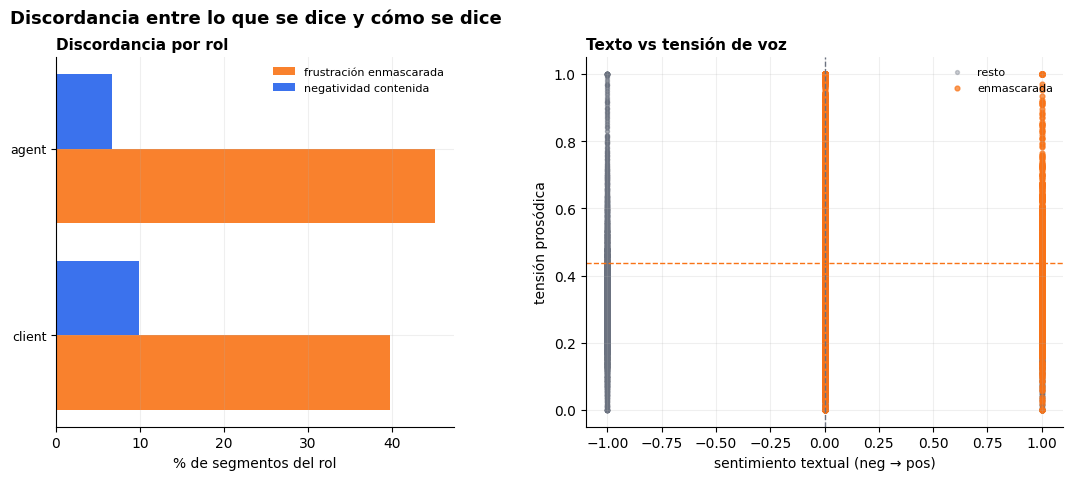

**Ejemplos de frustración enmascarada (texto neutro/positivo, voz tensa):**

,audio_stem_norm,role,interval,sentiment_label_norm,sentiment_numeric,tension_proxy_score,arousal_proxy_score,ser_neg_prob
35812,raw_bajas_9157452583930006851_clean,client,02:04.52 - 02:08.35,neutral,0.0,1.0,0.832695,0.191506
35837,raw_bajas_9157452583930006851_clean,client,03:59.28 - 04:02.00,neutral,0.0,1.0,1.000000,0.229457
35835,raw_bajas_9157452583930006851_clean,client,03:51.52 - 03:54.68,neutral,0.0,1.0,0.799375,0.183011
35832,raw_bajas_9157452583930006851_clean,client,03:34.38 - 03:35.10,neutral,0.0,1.0,0.766901,0.180107
5863,raw_bajas_9156122561940006851_clean,client,01:51.74 - 01:54.85,neutral,0.0,1.0,0.552960,0.183766
5835,raw_bajas_9156122004110016851_clean,client,02:26.76 - 02:27.52,neutral,0.0,1.0,0.953614,0.155368
35827,raw_bajas_9157452583930006851_clean,client,03:11.58 - 03:15.34,neutral,0.0,1.0,0.992068,0.182487
30815,raw_bajas_9157331401960006851_clean,client,00:15.39 - 00:18.61,neutral,0.0,1.0,1.000000,0.193790
34687,raw_bajas_9157399657500016851_clean,agent,02:34.50 - 02:35.47,neutral,0.0,1.0,0.778023,0.184538
1593,raw_9154939063420006851_clean,client,00:32.40 - 00:36.53,neutral,0.0,1.0,0.653577,0.192786


In [6]:
# ============================================================
# CELDA 6 - FASE 3 · DISCORDANCIA: FRUSTRACIÓN ENMASCARADA
# ============================================================
# El hallazgo más valioso del cruce: segmentos donde el TEXTO es
# neutro/positivo pero la VOZ muestra alta activación/tensión.
# En un call center esto es frustración no explícita en las palabras.

sec("Fase 3 · Discordancia (frustración enmascarada)",
    "Segmentos con texto neutro/positivo pero voz tensa o activada, y el caso inverso (negatividad contenida).")

df_disc = pd.DataFrame()
if not df_cmp.empty:
    d = df_cmp.copy()

    # Umbrales de "audio alto" por percentil del corpus comparable
    thr = {}
    for c in ["tension_proxy_score", "arousal_proxy_score", "ser_neg_prob"]:
        if c in d.columns and d[c].notna().any():
            thr[c] = np.nanpercentile(d[c], AUDIO_HIGH_PERCENTILE)

    audio_negative = pd.Series(False, index=d.index)
    if "tension_proxy_score" in thr:
        audio_negative |= d["tension_proxy_score"] >= thr["tension_proxy_score"]
    if "arousal_proxy_score" in thr:
        audio_negative |= d["arousal_proxy_score"] >= thr["arousal_proxy_score"]
    if "ser_neg_prob" in thr:
        audio_negative |= d["ser_neg_prob"] >= thr["ser_neg_prob"]

    text_nonneg = d["sentiment_numeric"] >= TEXT_NONNEG_THRESHOLD
    text_neg = d["sentiment_numeric"] < TEXT_NONNEG_THRESHOLD

    d["masked_frustration"] = text_nonneg & audio_negative      # texto ok, voz tensa
    d["contained_negativity"] = text_neg & (~audio_negative)     # texto negativo, voz calmada

    df_disc = d

    n = len(d)
    n_mask = int(d["masked_frustration"].sum())
    n_cont = int(d["contained_negativity"].sum())
    kpis({
        "segmentos comparables": n,
        "frustración enmascarada": n_mask,
        "% enmascarada": round(100 * n_mask / max(1, n), 1),
        "negatividad contenida": n_cont,
    })

    # Panel: tasa de discordancia por rol + dispersión texto vs tensión
    fig = plt.figure(figsize=(13, 4.8))
    gs = GridSpec(1, 2, wspace=0.3, width_ratios=[1, 1.2])

    ax0 = fig.add_subplot(gs[0])
    if "role" in d.columns:
        by_role = d.groupby("role")[["masked_frustration", "contained_negativity"]].mean() * 100
        by_role = by_role.sort_values("masked_frustration")
        y = np.arange(len(by_role))
        ax0.barh(y - 0.2, by_role["masked_frustration"], height=0.4, color=NARANJA, alpha=0.9, label="frustración enmascarada")
        ax0.barh(y + 0.2, by_role["contained_negativity"], height=0.4, color=AZUL, alpha=0.9, label="negatividad contenida")
        ax0.set_yticks(y); ax0.set_yticklabels(by_role.index.astype(str), fontsize=9)
        ax0.set_xlabel("% de segmentos del rol"); ax0.set_title("Discordancia por rol", fontsize=11, loc="left")
        ax0.legend(fontsize=8, frameon=False)

    ax1 = fig.add_subplot(gs[1])
    if "tension_proxy_score" in d.columns:
        sub = d[["sentiment_numeric", "tension_proxy_score", "masked_frustration"]].dropna()
        ax1.scatter(sub.loc[~sub["masked_frustration"], "sentiment_numeric"],
                    sub.loc[~sub["masked_frustration"], "tension_proxy_score"],
                    s=8, c=GRIS, alpha=0.35, label="resto")
        ax1.scatter(sub.loc[sub["masked_frustration"], "sentiment_numeric"],
                    sub.loc[sub["masked_frustration"], "tension_proxy_score"],
                    s=12, c=NARANJA, alpha=0.7, label="enmascarada")
        ax1.axvline(TEXT_NONNEG_THRESHOLD, color=GRIS, ls="--", lw=1)
        if "tension_proxy_score" in thr:
            ax1.axhline(thr["tension_proxy_score"], color=NARANJA, ls="--", lw=1)
        ax1.set_xlabel("sentimiento textual (neg → pos)"); ax1.set_ylabel("tensión prosódica")
        ax1.set_title("Texto vs tensión de voz", fontsize=11, loc="left")
        ax1.legend(fontsize=8, frameon=False)

    fig.suptitle("Discordancia entre lo que se dice y cómo se dice", fontsize=13, fontweight="bold", x=0.09, ha="left")
    plt.savefig(FIGURES_DIR / "fase3_discordancia.png", dpi=120, bbox_inches="tight", facecolor="white")
    plt.show()

    # Ejemplos top de frustración enmascarada (para la memoria / defensa)
    cols_show = [c for c in ["audio_stem_norm", "role", "interval", "text_whisper",
                             "sentiment_label_norm", "sentiment_numeric",
                             "tension_proxy_score", "arousal_proxy_score", "ser_neg_prob"] if c in d.columns]
    top_masked = d[d["masked_frustration"]].sort_values("tension_proxy_score", ascending=False)[cols_show].head(12)
    if not top_masked.empty:
        display(Markdown("**Ejemplos de frustración enmascarada (texto neutro/positivo, voz tensa):**"))
        display(top_masked)
    note("Estos casos son el argumento central del cruce multimodal: el análisis textual por sí solo "
         "los habría clasificado como neutrales, perdiendo señal de insatisfacción que sí capta la voz.")
else:
    note("No hay segmentos comparables para el análisis de discordancia.")


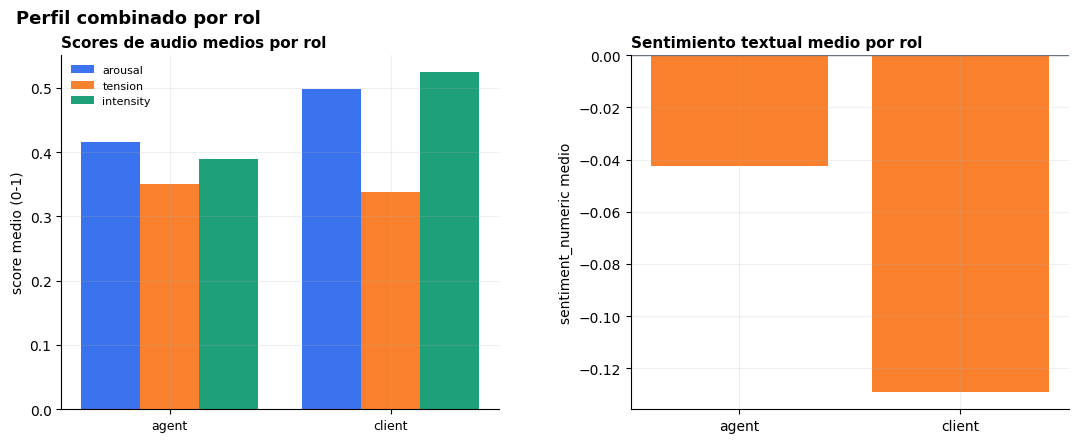

**Resumen por rol:**

,role,sentiment_numeric,arousal_proxy_score,tension_proxy_score,intensity_proxy_score,ser_neg_prob,masked_frustration,contained_negativity,n_segmentos
0,agent,-0.042,0.416,0.351,0.389,0.179,0.451,0.066,17639
1,client,-0.129,0.498,0.338,0.525,0.165,0.397,0.099,14554


In [7]:
# ============================================================
# CELDA 7 - FASE 4 · PERFIL POR ROL Y AGREGACIONES
# ============================================================
# Resumen por rol (agente/cliente) y por llamada, combinando ambas
# modalidades. Base para las conclusiones de la memoria.

sec("Fase 4 · Perfil por rol y agregaciones",
    "Comparación agente vs cliente combinando texto y audio, y agregados por llamada.")

df_role = pd.DataFrame()
df_call = pd.DataFrame()

if not df_cmp.empty:
    agg_map = {}
    for c in ["sentiment_numeric", "arousal_proxy_score", "tension_proxy_score",
              "intensity_proxy_score", "ser_neg_prob"]:
        if c in df_disc.columns:
            agg_map[c] = "mean"
    disc_map = {}
    for c in ["masked_frustration", "contained_negativity"]:
        if c in df_disc.columns:
            disc_map[c] = "mean"

    # Por rol
    if agg_map or disc_map:
        df_role = df_disc.groupby("role").agg({**agg_map, **disc_map})
        df_role["n_segmentos"] = df_disc.groupby("role").size()
        df_role = df_role.reset_index()

    # Por llamada + rol
    if "audio_stem_norm" in df_disc.columns and (agg_map or disc_map):
        df_call = df_disc.groupby(["audio_stem_norm", "role"]).agg({**agg_map, **disc_map})
        df_call["n_segmentos"] = df_disc.groupby(["audio_stem_norm", "role"]).size()
        df_call = df_call.reset_index()

    if not df_role.empty:
        # Panel resumen por rol
        fig = plt.figure(figsize=(13, 4.6))
        gs = GridSpec(1, 2, wspace=0.3)

        ax0 = fig.add_subplot(gs[0])
        score_cols = [c for c in ["arousal_proxy_score", "tension_proxy_score", "intensity_proxy_score"] if c in df_role.columns]
        x = np.arange(len(df_role)); w = 0.8 / max(1, len(score_cols))
        for i, c in enumerate(score_cols):
            ax0.bar(x + i * w, df_role[c], width=w, label=c.replace("_proxy_score", ""), alpha=0.9)
        ax0.set_xticks(x + w * (len(score_cols) - 1) / 2); ax0.set_xticklabels(df_role["role"], fontsize=9)
        ax0.set_title("Scores de audio medios por rol", fontsize=11, loc="left")
        ax0.legend(fontsize=8, frameon=False); ax0.set_ylabel("score medio (0-1)")

        ax1 = fig.add_subplot(gs[1])
        if "sentiment_numeric" in df_role.columns:
            colors = [VERDE if v >= 0 else NARANJA for v in df_role["sentiment_numeric"]]
            ax1.bar(df_role["role"], df_role["sentiment_numeric"], color=colors, alpha=0.9)
            ax1.axhline(0, color=GRIS, lw=1)
            ax1.set_title("Sentimiento textual medio por rol", fontsize=11, loc="left")
            ax1.set_ylabel("sentiment_numeric medio")
        fig.suptitle("Perfil combinado por rol", fontsize=13, fontweight="bold", x=0.09, ha="left")
        plt.savefig(FIGURES_DIR / "fase4_perfil_rol.png", dpi=120, bbox_inches="tight", facecolor="white")
        plt.show()

        display(Markdown("**Resumen por rol:**"))
        display(df_role.round(3))
else:
    note("No hay segmentos comparables para las agregaciones por rol.")


## Guardar resultados

Todos los CSV generados en este notebook, listos para citarse en la memoria o alimentar el dashboard ejecutivo final del Notebook 10.

In [8]:
# ============================================================
# CELDA 8 - GUARDAR OUTPUTS + SUBIDA OPCIONAL A GCS
# ============================================================

sec("Guardar outputs de la fusión", "CSV segment-level, correlaciones, confusión, discordancia y agregados.")

saved = []

def _save(df, path, label):
    if isinstance(df, pd.DataFrame) and not df.empty:
        df.to_csv(path, index=False)
        saved.append((label, str(path), len(df)))
        return True
    return False

# segment-level fusionado (con flags de discordancia si existen)
seg_out = df_disc if ("df_disc" in dir() and isinstance(df_disc, pd.DataFrame) and not df_disc.empty) else df_fusion
_save(seg_out, FUSION_SEGMENTS_CSV, "segmentos fusionados")
_save(df_corr if "df_corr" in dir() else pd.DataFrame(), CORRELATIONS_CSV, "correlaciones")
if "conf" in dir() and isinstance(conf, pd.DataFrame) and not conf.empty:
    conf.to_csv(CONFUSION_CSV)
    saved.append(("matriz de confusión", str(CONFUSION_CSV), conf.shape[0]))
# ejemplos de discordancia
if "df_disc" in dir() and isinstance(df_disc, pd.DataFrame) and "masked_frustration" in df_disc.columns:
    _save(df_disc[df_disc["masked_frustration"]], DISAGREEMENT_SEGMENTS_CSV, "frustración enmascarada")
_save(df_role if "df_role" in dir() else pd.DataFrame(), ROLE_LEVEL_CSV, "agregado por rol")
_save(df_call if "df_call" in dir() else pd.DataFrame(), CALL_LEVEL_CSV, "agregado por llamada")

# resumen compacto para la memoria
summary_rows = []
if not df_fusion.empty:
    both = int((df_fusion["has_audio"] & df_fusion["has_text"]).sum())
    summary_rows.append({"metrica": "segmentos_totales", "valor": len(df_fusion)})
    summary_rows.append({"metrica": "segmentos_comparables", "valor": both})
if "df_corr" in dir() and not df_corr.empty:
    for _, r in df_corr.iterrows():
        summary_rows.append({"metrica": f"pearson_{r['score_audio']}", "valor": r["pearson_r"]})
if "df_disc" in dir() and "masked_frustration" in df_disc.columns and len(df_disc):
    summary_rows.append({"metrica": "pct_frustracion_enmascarada",
                         "valor": round(100 * df_disc["masked_frustration"].mean(), 2)})
df_summary = pd.DataFrame(summary_rows)
_save(df_summary, SUMMARY_MEMORY_CSV, "resumen para memoria")

if saved:
    display(pd.DataFrame(saved, columns=["output", "ruta", "filas"]))
else:
    note("No se guardó ningún output (faltan datos de entrada).")

# --- GCS opcional ---
if UPLOAD_TO_GCS and GCS_AVAILABLE and GCS_BUCKET_NAME:
    try:
        client = storage.Client()
        bucket = client.bucket(GCS_BUCKET_NAME)
        for _, path, _ in saved:
            blob = bucket.blob(f"{GCS_PREFIX}/{Path(path).name}")
            blob.upload_from_filename(path)
        print("Outputs subidos a GCS:", GCS_BUCKET_NAME)
    except Exception as e:
        print("No se pudo subir a GCS:", e)
else:
    print("Subida a GCS desactivada o no configurada.")


,output,ruta,filas
0,segmentos fusionados,/home/jupyter/TFM_ProcesadoDeAudios/data/senti...,32193
1,correlaciones,/home/jupyter/TFM_ProcesadoDeAudios/data/senti...,4
2,matriz de confusión,/home/jupyter/TFM_ProcesadoDeAudios/data/senti...,4
3,frustración enmascarada,/home/jupyter/TFM_ProcesadoDeAudios/data/senti...,13745
4,agregado por rol,/home/jupyter/TFM_ProcesadoDeAudios/data/senti...,2
5,agregado por llamada,/home/jupyter/TFM_ProcesadoDeAudios/data/senti...,2332
6,resumen para memoria,/home/jupyter/TFM_ProcesadoDeAudios/data/senti...,7


Subida a GCS desactivada o no configurada.


## Cómo usar este notebook en la defensa

1. Empezar por la **cobertura** (Fase 1): deja claro sobre cuántos datos se sostiene la comparación.
2. Mostrar la **concordancia** (Fase 2): las correlaciones moderadas justifican que ambas modalidades aportan información distinta, no redundante.
3. El punto fuerte es la **Fase 3 (discordancia)**: los ejemplos de frustración enmascarada son el argumento más defendible del cruce multimodal — el texto solo no los detecta.
4. Cerrar con el **perfil por rol** (Fase 4): si el agente mantiene un perfil de audio más estable que el cliente, es una observación operativa con valor práctico para un call center.

Los CSV de esta fusión (`segments_audio_text_fusion.csv`, `role_level_audio_text_fusion.csv`, etc.) quedan listos para alimentar tanto la memoria escrita como el dashboard ejecutivo final del Notebook 10.